<a href="https://colab.research.google.com/github/Elwing-Chou/ximen_ai_20260706/blob/main/ximen20260713.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


```
age age in years
sex
bmi body mass index
bp average blood pressure
s1 tc, total serum cholesterol
s2 ldl, low-density lipoproteins
s3 hdl, high-density lipoproteins
s4 tch, total cholesterol / HDL
s5 ltg, possibly log of serum triglycerides level
s6 glu, blood sugar level
```



In [2]:
# Step 1. 把你的資料整理成一個表格
# 哪個特徵重要: 不是你決定了, 是模型決定的
# 如果特徵有相關性呢? 你不用去掉某個, 模型決定哪個好, 用哪個
# 準備資料(x): 越多越好

import pandas as pd
from sklearn.datasets import load_diabetes

data = load_diabetes(scaled=False)

df = pd.DataFrame(data["data"],
                  columns=data["feature_names"])
df["target"] = data["target"]
df.to_csv("diabetes.csv", encoding="utf-8", index=False)
df

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,59.0,2.0,32.1,101.00,157.0,93.2,38.0,4.00,4.8598,87.0,151.0
1,48.0,1.0,21.6,87.00,183.0,103.2,70.0,3.00,3.8918,69.0,75.0
2,72.0,2.0,30.5,93.00,156.0,93.6,41.0,4.00,4.6728,85.0,141.0
3,24.0,1.0,25.3,84.00,198.0,131.4,40.0,5.00,4.8903,89.0,206.0
4,50.0,1.0,23.0,101.00,192.0,125.4,52.0,4.00,4.2905,80.0,135.0
...,...,...,...,...,...,...,...,...,...,...,...
437,60.0,2.0,28.2,112.00,185.0,113.8,42.0,4.00,4.9836,93.0,178.0
438,47.0,2.0,24.9,75.00,225.0,166.0,42.0,5.00,4.4427,102.0,104.0
439,60.0,2.0,24.9,99.67,162.0,106.6,43.0,3.77,4.1271,95.0,132.0
440,36.0,1.0,30.0,95.00,201.0,125.2,42.0,4.79,5.1299,85.0,220.0


In [ ]:
# Step 2. 評估一下你的資料到底夠不夠
# 機器學習: 千筆以上
# 深度學習: 萬筆以上
# 問題複雜度: 複雜度(有效輸入越多個)越高, 越多資料

# Step 3. 分成兩部分
# 1. 訓練資料(給你的模型訓練)  2. 驗證資料(驗證模型用)
from sklearn.model_selection import train_test_split
# train_test_split([1, 2, 3, 4],
#                  [5, 6, 7, 8],
#                  [10, 11, 12, 13],
#                  test_size=0.25)
# x, y分出來
# drop():  pandas只要看到axis參數, 只有兩種0 和 1, 不同方向
# demo = pd.DataFrame([
#     [1, 2],
#     [3, 4]
# ], columns=["a", "b"], index=["a", "b"])
# demo.drop("a", axis=1)
x = df.drop("target", axis=1)
y = df["target"]
# x 80, x 20, y 80, y 20
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)
y_train

,target
11,0
41,0
38,0
130,2
76,1
...,...
92,1
113,2
117,2
148,2


In [ ]:
# Step 4. 建立模型
from sklearn.tree import DecisionTreeClassifier
# 過擬合: 任何模型都要防止, 防止過度學習訓練資料
# 因為過度學習訓練資料, 通常反而會在現實資料表現得很差
# 調參大部分時候就是為了控制這個擬合程度
clf = DecisionTreeClassifier(max_depth=2)
clf.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=2)

[Text(0.4, 0.8333333333333334, 'petal width (cm) <= 0.8\ngini = 0.666\nsamples = 120\nvalue = [39, 39, 42]\nclass = virginica'),
 Text(0.2, 0.5, 'gini = 0.0\nsamples = 39\nvalue = [39, 0, 0]\nclass = setosa'),
 Text(0.30000000000000004, 0.6666666666666667, 'True  '),
 Text(0.6, 0.5, 'petal width (cm) <= 1.75\ngini = 0.499\nsamples = 81\nvalue = [0, 39, 42]\nclass = virginica'),
 Text(0.5, 0.6666666666666667, '  False'),
 Text(0.4, 0.16666666666666666, 'gini = 0.206\nsamples = 43\nvalue = [0, 38, 5]\nclass = versicolor'),
 Text(0.8, 0.16666666666666666, 'gini = 0.051\nsamples = 38\nvalue = [0, 1, 37]\nclass = virginica')]

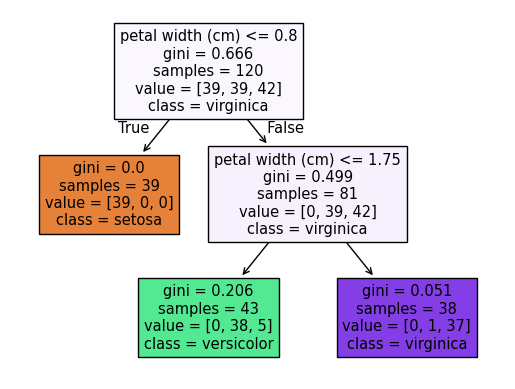

In [ ]:
from sklearn.tree import plot_tree
plot_tree(clf,
          feature_names=x.columns,
          filled=True,
          class_names=data["target_names"],
          max_depth=2)

In [ ]:
# Step 5. 用測試資料確認參數
from sklearn.metrics import accuracy_score
pre = clf.predict(x_test)
accuracy_score(y_test, pre)

1.0

In [ ]:
# 分類metrics: 如果只用accuracy score會在imbalanced datasets有問題
# 不平衡的話, 你乾脆不用分就好
# accuracy: 一般情況都好用
# precision/recall/f1: imbalanced好用
# Precision(精確): 有多少真的是1/你預測是1的
# Recall(召回): 你判斷出來多少個1/母體有多少是1的
# Precision和Recall是Trade-off
# Precision: 嚴謹, 不錯殺. 寧可放過
# Recall: 寧可錯殺, 不放過
# f1 score: PR和RE的調和平均 2PRxRe/(PR+RE)
# 會反映小值: 避免你做出過度的犧牲(0.6-0.7以上我就覺得不錯了)
from sklearn.metrics import classification_report
print(classification_report(y_test, pre))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00      1.00        11
           2       1.00      1.00      1.00         8

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

